Анатолий Ботов ки22-08б

# Задание 6. Применение многослойной (неглубокой) нейронной сети прямого распространения - FFNN - для задач классификации и регрессии.

## Часть 1. Бинарный классификатор на базе FFNN  
## Порядок работы:  
### 1. Подключение библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sklearn as skl
import sklearn.metrics as sklm
import tensorflow as tf
from tensorflow import keras as tfk

np.random.seed(2025)
tf.random.set_seed(2025)

# Примечание: даже с этими настройками мелкие отличия при запуске на разных машинах всё равно возможны.

### 2. Загрузка датасета

In [3]:
df = pd.read_csv("cars_onehot.csv")
df = df.drop(
    "Mileage_per_year", axis=1
)  # Если не удалить, очень сильно падает точность
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33894 entries, 0 to 33893
Columns: 116 entries, Year to Fuel_type_Plug-in Hybrid
dtypes: bool(103), float64(12), int64(1)
memory usage: 6.7 MB


,Year,Distance,Engine_capacity(cm3),Transmission,Price(euro),Year_norm,Distance_log,Engine_capacity_log,Price_log,Distance_std,...,Style_Minivan,Style_Pickup,Style_SUV,Style_Sedan,Style_Universal,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
0,2011.0,195000.0,1800.0,1,7750.0,0.756098,12.180760,7.496097,8.955577,0.397962,...,False,False,False,False,False,False,True,False,False,False
1,2014.0,135000.0,1500.0,0,8550.0,0.829268,11.813037,7.313887,9.053804,0.267627,...,False,False,False,False,True,False,False,False,False,False
2,1998.0,1.0,1400.0,0,2200.0,0.439024,0.693147,7.244942,7.696667,-3.673671,...,False,False,False,False,False,False,False,False,True,False
3,2012.0,110000.0,1500.0,0,6550.0,0.780488,11.608245,7.313887,8.787373,0.195041,...,False,False,False,False,True,False,False,False,False,False
4,2006.0,200000.0,1600.0,0,4100.0,0.634146,12.206078,7.378384,8.318986,0.406935,...,False,False,False,False,True,False,False,True,False,False


### 3. Бинарная классификация: подготовка данных для обучения и тестирования модели  

In [4]:
from sklearn.model_selection import train_test_split

# Деление исходной таблицы на обучающую и валидационную части
features_train_bin, features_valid_bin = train_test_split(df, test_size=0.2, train_size=0.8, shuffle=False)

labels_train_bin = features_train_bin['Transmission']
features_train_bin = features_train_bin.drop(columns='Transmission')

labels_valid_bin = features_valid_bin['Transmission']
features_valid_bin = features_valid_bin.drop(columns='Transmission')

### 4. Построение модели нейронной сети для задачи бинарной классификации

#### 4.2. Описание модели нейронной сети на базе класса Sequential с использованием конструктора класса

In [5]:
bin_classifier = tfk.models.Sequential()
bin_classifier.add(tfk.Input(shape=[features_train_bin.shape[1]]))
bin_classifier.add(tfk.layers.Dense(8, activation='relu'))
bin_classifier.add(tfk.layers.Dense(4, activation='relu'))
bin_classifier.add(tfk.layers.Dense(2, activation='relu'))
bin_classifier.add(tfk.layers.Dense(1, activation='sigmoid'))

#### 4.3. Компиляция модели нейронной сети с соответствующими параметрами

In [6]:
bin_classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
bin_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 977 (3.82 KB)

 Trainable params: 977 (3.82 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Обучение модели

In [7]:
train_history_bin = bin_classifier.fit(
    features_train_bin, labels_train_bin,
    batch_size=32, validation_split=0.2,
    verbose=1, epochs=8
)

Epoch 1/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5091 - loss: 0.6930 - val_accuracy: 0.5836 - val_loss: 0.6873
Epoch 2/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5138 - loss: 0.6928 - val_accuracy: 0.5836 - val_loss: 0.6865
Epoch 3/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - val_loss: 0.6864
Epoch 4/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - val_loss: 0.6864
Epoch 5/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - val_loss: 0.6864
Epoch 6/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - val_loss: 0.6864
Epoch 7/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - val_loss: 0.6864
Epoch 8/8
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5138 - loss: 0.6929 - val_accuracy: 0.5836 - v

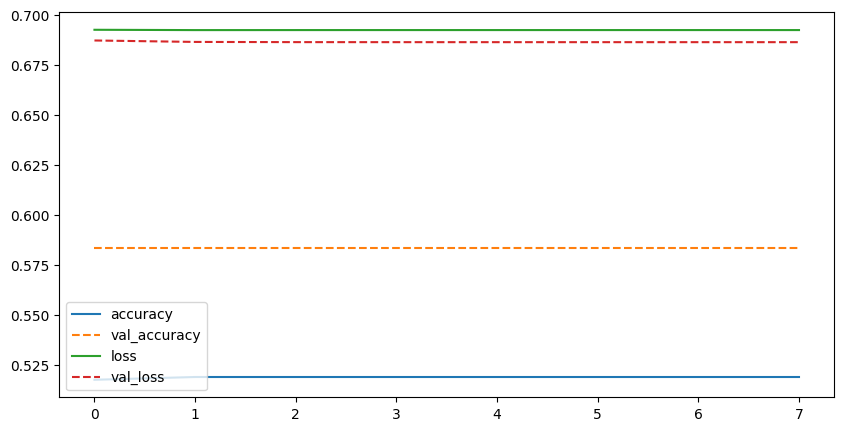

In [54]:
plt.subplots(figsize=(10, 5))
plt.plot(train_history_bin.history['accuracy'], label='accuracy')
plt.plot(train_history_bin.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(train_history_bin.history['loss'], label='loss')
plt.plot(train_history_bin.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()

### 6. Оценка качества работы полученного классификатора  

### 6.1 Проверка работоспособности классификатора

In [9]:
_, acc_train_bin = bin_classifier.evaluate(features_train_bin, labels_train_bin)
_, acc_valid_bin = bin_classifier.evaluate(features_valid_bin, labels_valid_bin)
print(f'Точность на обучающей выборке: {acc_train_bin}')
print(f'Точность на валидационной выборке: {acc_valid_bin}')

848/848 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step - accuracy: 0.5039 - loss: 0.6939
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.5828 - loss: 0.6865
Точность на обучающей выборке: 0.5319564938545227
Точность на валидационной выборке: 0.5900575518608093


### 6.2 Оценка работы классификатора по показателю "нулевая точность" - null_accuracy

In [10]:
_, acc_train_bin = bin_classifier.evaluate(features_train_bin, labels_train_bin)
_, acc_valid_bin = bin_classifier.evaluate(features_valid_bin, labels_valid_bin)
print(f'Точность на обучающей выборке: {acc_train_bin}')
print(f'Точность на валидационной выборке: {acc_valid_bin}')

848/848 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5039 - loss: 0.6939
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5828 - loss: 0.6865
Точность на обучающей выборке: 0.5319564938545227
Точность на валидационной выборке: 0.5900575518608093


### 6.3. Определение метрик качества модели

In [11]:
def binary_metrics_eval(true_labels, predicted_labels):
    conf_matrix = sklm.confusion_matrix(true_labels, predicted_labels)
    tn, fp, fn, tp = conf_matrix.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp)
    rec = tp / (tp + fn)
    spec = tn / (tn + fp)

    print(f'Доля верных ответов  : {acc:.4f}')
    print(f'Точность (precision) : {prec:.4f}')
    print(f'Полнота (recall)     : {rec:.4f}')
    print(f'Специфичность        : {spec:.4f}')

    annot_labels = np.array([
        [f"TN: {tn}", f"FP: {fp}"],
        [f"FN: {fn}", f"TP: {tp}"]
    ])

    plt.figure(figsize=(5,3))
    matrix_df = pd.DataFrame(
        data=conf_matrix,
        index=['Факт: Нет', 'Факт: Да'],
        columns=['Прогноз: Нет', 'Прогноз: Да']
    )
    sns.heatmap(matrix_df, annot=annot_labels, fmt='', cmap='coolwarm')
    plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step
Доля верных ответов  : 0.5901
Точность (precision) : nan
Полнота (recall)     : 0.0000
Специфичность        : 1.0000


C:\Users\tolya\AppData\Local\Temp\ipykernel_12224\4018398791.py:6: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


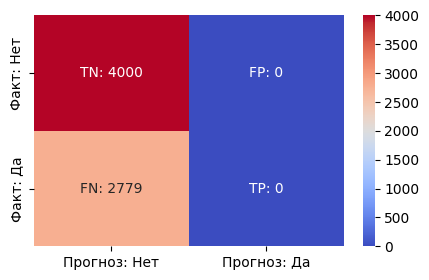

In [12]:
binary_metrics_eval(
    labels_valid_bin,
    (bin_classifier.predict(features_valid_bin) > 0.5).astype(int)
)

## Часть 2. Применение многослойных нейронных сетей FFNN для решения задачи многоклассовой классификации  
## Порядок работы:

### 3. Многоклассовая классификация: подготовка данных для обучения и тестирования модели

#### 3.2. Подготовка тестовой и обучающей выборки

In [35]:
from sklearn.model_selection import train_test_split

# Деление данных на обучающую и валидационную выборки для многоклассовой задачи
features_train_multi, features_valid_multi = train_test_split(df, test_size=0.2, train_size=0.8, shuffle=False)

fuel_columns = [
    "Fuel_type_Electric",
    "Fuel_type_Hybrid",
    "Fuel_type_Metan/Propan",
    "Fuel_type_Petrol",
    "Fuel_type_Plug-in Hybrid",
]
labels_train_multi = features_train_multi[fuel_columns]
features_train_multi = features_train_multi.drop(columns=fuel_columns)

labels_valid_multi = features_valid_multi[fuel_columns]
features_valid_multi = features_valid_multi.drop(columns=fuel_columns)

labels_train_multi.head()

,Fuel_type_Electric,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid
0,False,True,False,False,False
1,False,False,False,False,False
2,False,False,False,True,False
3,False,False,False,False,False
4,False,False,True,False,False


### 4. Построение модели нейронной сети для задачи бинарной классификации

#### 4.2. Описание модели нейронной сети на базе класса Sequential с использованием метода `add`

In [36]:
multi_classifier = tfk.models.Sequential()
multi_classifier.add(tfk.Input(shape=[features_train_multi.shape[1]]))
multi_classifier.add(tfk.layers.Dense(128, activation='relu'))
multi_classifier.add(tfk.layers.BatchNormalization())
multi_classifier.add(tfk.layers.Dropout(0.3))
multi_classifier.add(tfk.layers.Dense(256, activation='relu'))
multi_classifier.add(tfk.layers.BatchNormalization())
multi_classifier.add(tfk.layers.Dropout(0.3))
multi_classifier.add(tfk.layers.Dense(128, activation='relu'))
multi_classifier.add(tfk.layers.BatchNormalization())
multi_classifier.add(tfk.layers.Dropout(0.2))
multi_classifier.add(tfk.layers.Dense(5, activation="softmax"))

#### 4.3. Компиляция модели нейронной сети с соответствующими параметрами

In [37]:
multi_classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
multi_classifier.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,949 (324.02 KB)

 Trainable params: 81,925 (320.02 KB)

 Non-trainable params: 1,024 (4.00 KB)

### 5. Обучение модели

In [38]:
cb_early_stop_multi = tfk.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

train_log_multi = multi_classifier.fit(
    features_train_multi, labels_train_multi,
    batch_size=32, validation_split=0.2,
    verbose=1, epochs=16,
    callbacks=[cb_early_stop_multi]
)

Epoch 1/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2732 - loss: 0.7308 - val_accuracy: 0.3369 - val_loss: 0.4901
Epoch 2/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2863 - loss: 0.6096 - val_accuracy: 0.3358 - val_loss: 0.5202
Epoch 3/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2820 - loss: 0.6684 - val_accuracy: 0.3362 - val_loss: 0.5237
Epoch 4/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2839 - loss: 0.6920 - val_accuracy: 0.3365 - val_loss: 0.5348
Epoch 5/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2887 - loss: 0.6843 - val_accuracy: 0.3351 - val_loss: 0.5097
Epoch 6/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2917 - loss: 0.6689 - val_accuracy: 0.2989 - val_loss: 0.5292


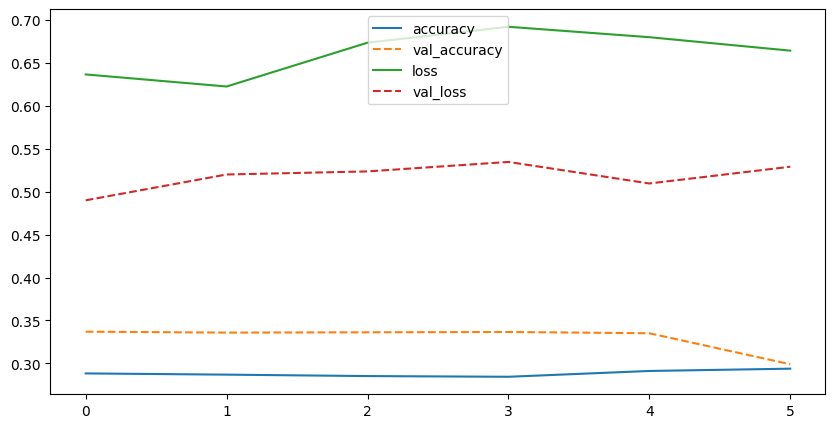

Fuel_type_Electric            24
Fuel_type_Hybrid            1623
Fuel_type_Metan/Propan      2892
Fuel_type_Petrol            8998
Fuel_type_Plug-in Hybrid     383
dtype: int64


In [ ]:
plt.subplots(figsize=(10, 5))
plt.plot(train_log_multi.history['accuracy'], label='accuracy')
plt.plot(train_log_multi.history['val_accuracy'], label='val_accuracy', linestyle='--')
plt.plot(train_log_multi.history['loss'], label='loss')
plt.plot(train_log_multi.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()

### 6. Оценка качества работы многоклассового классификатора  

### 6.1 Проверка работоспособности классификатора

In [40]:
_, acc_train_multi = multi_classifier.evaluate(features_train_multi, labels_train_multi)
_, acc_valid_multi = multi_classifier.evaluate(features_valid_multi, labels_valid_multi)
print(f'Точность на обучающей выборке: {acc_train_multi:.4f}')
print(f'Точность на валидационной выборке: {acc_valid_multi:.4f}')

848/848 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3208 - loss: 0.5281
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3732 - loss: 0.5210
Точность на обучающей выборке: 0.3305
Точность на валидационной выборке: 0.3676


### 6.2. Определение метрик качества классификатора

In [43]:
def multiclass_metrics_eval(true_labels, predicted_labels):
    cm = sklm.confusion_matrix(true_labels, predicted_labels)

    print(
        f"Доля верных ответов      : {sklm.accuracy_score(true_labels, predicted_labels):.4f}"
    )
    print(
        f'Средневзвешенная точность: {sklm.precision_score(true_labels, predicted_labels, average="weighted"):.4f}'
    )
    print(
        f'Средневзвешенная полнота : {sklm.recall_score(true_labels, predicted_labels, average="weighted"):.4f}'
    )

    plt.figure(figsize=(8, 6))
    plt.title("Матрица ошибок (Confusion Matrix)")
    class_labels = [
        "Electric",
        "Hybrid",
        "Metan/Propan",
        "Petrol",
        "Plug-in Hybrid",
    ]  # исправлено!
    cm_matrix = pd.DataFrame(data=cm, index=class_labels, columns=class_labels)
    sns.heatmap(cm_matrix, annot=True, fmt="", cmap="coolwarm", norm=mcolors.LogNorm())
    plt.xlabel("Предсказание")
    plt.ylabel("Факт")
    plt.show()

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step
Доля верных ответов      : 0.3676
Средневзвешенная точность: 0.1521
Средневзвешенная полнота : 0.3676


c:\Users\tolya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


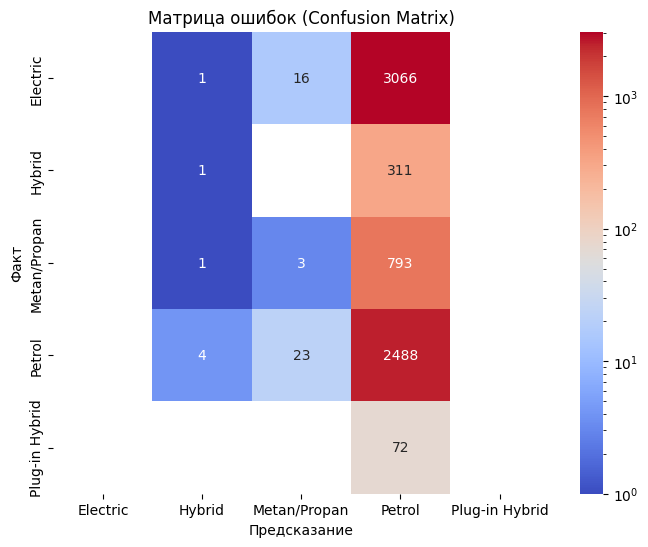

In [44]:
multiclass_metrics_eval(
    np.argmax(labels_valid_multi.values, axis=1),
    np.argmax(multi_classifier.predict(features_valid_multi), axis=1)
)

## Часть 3. Применение многослойных нейронных сетей FFNN для решения задачи регрессии  
## Порядок работы:

### 3. Регрессия: подготовка данных для обучения и тестирования модели

#### 3.1. Подготовка тестовой и обучающей выборки

In [45]:
from sklearn.model_selection import train_test_split

# Деление данных на обучающую и валидационную выборки для задачи регрессии
features_train_reg, features_valid_reg = train_test_split(df, test_size=0.2, train_size=0.8, shuffle=False)

target_column = 'Price(euro)'

labels_train_reg = features_train_reg[target_column]
features_train_reg = features_train_reg.drop(columns=[target_column])

labels_valid_reg = features_valid_reg[target_column]
features_valid_reg = features_valid_reg.drop(columns=[target_column])

### 4. Построение модели нейронной сети для задачи регрессии  

#### 4.2. Описание модели

In [46]:
regressor = tfk.models.Sequential()
regressor.add(tfk.Input(shape=[features_train_reg.shape[1]]))
regressor.add(tfk.layers.Dense(64, activation='relu'))
regressor.add(tfk.layers.Dropout(0.3))
regressor.add(tfk.layers.Dense(128, activation='relu'))
regressor.add(tfk.layers.Dropout(0.3))
regressor.add(tfk.layers.Dense(64, activation='relu'))
regressor.add(tfk.layers.Dropout(0.2))
regressor.add(tfk.layers.Dense(1, activation='relu'))

#### 4.3. Компиляция модели

In [47]:
regressor.compile(optimizer='adam', loss='mae', metrics=['mae'])
regressor.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,065 (94.00 KB)

 Trainable params: 24,065 (94.00 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Обучение модели  

In [48]:
cb_early_stop_reg = tfk.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

train_log_reg = regressor.fit(
    features_train_reg, labels_train_reg,
    batch_size=32, validation_split=0.2,
    verbose=1, epochs=16,
    callbacks=[cb_early_stop_reg]
)

Epoch 1/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7557.1055 - mae: 7557.1055 - val_loss: 4420.5356 - val_mae: 4420.5356
Epoch 2/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5085.5317 - mae: 5085.5317 - val_loss: 4629.7227 - val_mae: 4629.7227
Epoch 3/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4860.8789 - mae: 4860.8789 - val_loss: 4414.8545 - val_mae: 4414.8545
Epoch 4/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4788.3887 - mae: 4788.3887 - val_loss: 4615.2651 - val_mae: 4615.2651
Epoch 5/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4759.0620 - mae: 4759.0620 - val_loss: 4450.8638 - val_mae: 4450.8638
Epoch 6/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4699.1401 - mae: 4699.1401 - val_loss: 4395.4565 - val_mae: 4395.4565
Epoch 7/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4695.5059 - mae: 4695.5059 - val_loss: 4415.1343 - val_mae: 4415.1343
Epoch 8/16
678/678 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4695.9502 - mae: 4695.9502 - v

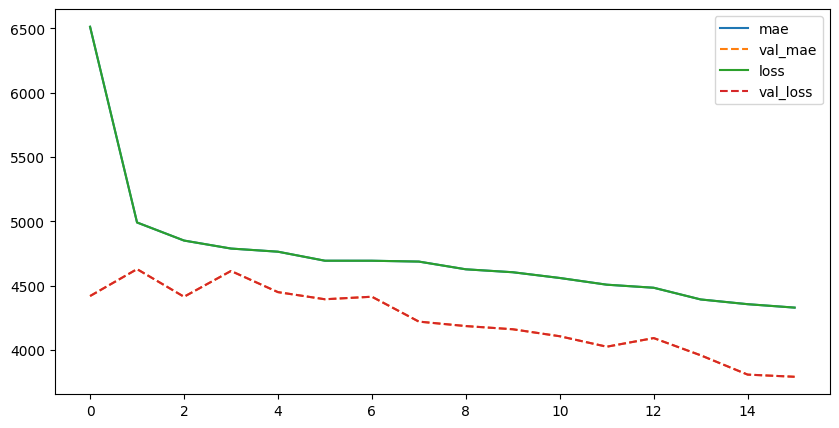

In [49]:
plt.subplots(figsize=(10, 5))
plt.plot(train_log_reg.history['mae'], label='mae')
plt.plot(train_log_reg.history['val_mae'], label='val_mae', linestyle='--')
plt.plot(train_log_reg.history['loss'], label='loss')
plt.plot(train_log_reg.history['val_loss'], label='val_loss', linestyle='--')
plt.legend()
plt.show()

### 6. Оценка качества работы полученного регрессора  
#### 6.1. Вычисление метрик качества  

In [52]:
def check_regression_metrics(model, features, labels):
    predictions = model.predict(features)
    metrics = []
    metrics.append(sklm.mean_absolute_error(labels, predictions))
    metrics.append(sklm.mean_absolute_percentage_error(labels, predictions))
    metrics.append(sklm.mean_squared_error(labels, predictions))
    metrics.append(sklm.r2_score(labels, predictions))
    return metrics

metrics_names = pd.DataFrame(['MAE', 'MAPE', 'MSE', 'R²'], columns=['Метрика'])
metrics_names['Regressor'] = pd.DataFrame(
    check_regression_metrics(regressor, features_valid_reg, labels_valid_reg)
)
metrics_names

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step


,Метрика,Regressor
0,MAE,3.910360e+03
1,MAPE,7.895558e-01
2,MSE,3.727571e+07
3,R²,4.204260e-01


#### 6.2. Визуализация полученных ответов и невязки

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


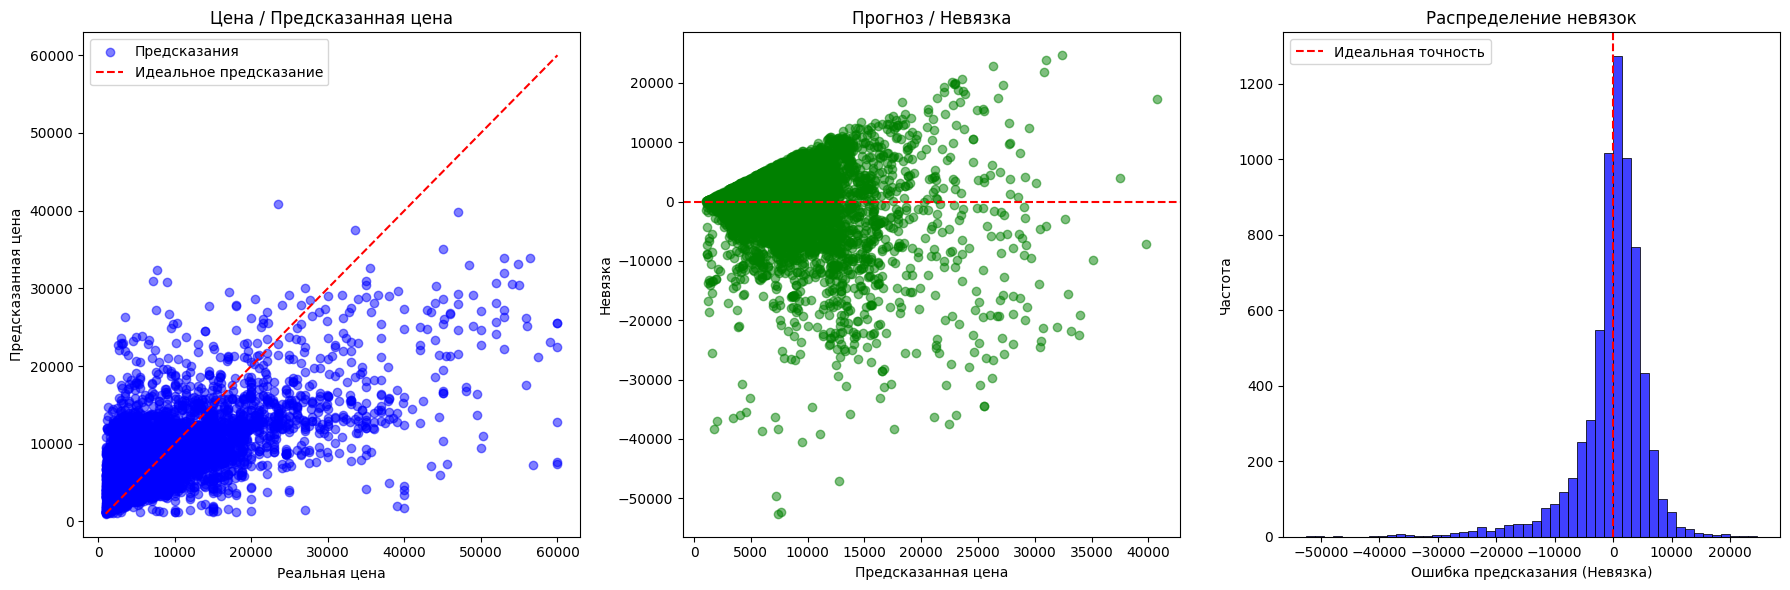

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

pred_valid_reg = regressor.predict(features_valid_reg).flatten()

# 1. Реальные против предсказанных значений
axs[0].scatter(labels_valid_reg, pred_valid_reg, alpha=0.5, color="blue", label="Предсказания")
axs[0].plot([min(labels_valid_reg), max(labels_valid_reg)],
            [min(labels_valid_reg), max(labels_valid_reg)],
            linestyle="--", color="red", label="Идеальное предсказание")
axs[0].set_xlabel("Реальная цена")
axs[0].set_ylabel("Предсказанная цена")
axs[0].set_title("Цена / Предсказанная цена")
axs[0].legend()

# 2. График невязок
errors = pred_valid_reg - labels_valid_reg
axs[1].scatter(pred_valid_reg, errors, alpha=0.5, color="green")
axs[1].axhline(y=0, color="red", linestyle="--")
axs[1].set_xlabel("Предсказанная цена")
axs[1].set_ylabel("Невязка")
axs[1].set_title("Прогноз / Невязка")

# 3. Гистограмма ошибок
sns.histplot(errors, bins=50, color="blue", ax=axs[2])
axs[2].axvline(x=0, color="red", linestyle="--", label="Идеальная точность")
axs[2].set_xlabel("Ошибка предсказания (Невязка)")
axs[2].set_ylabel("Частота")
axs[2].set_title("Распределение невязок")
axs[2].legend()

plt.tight_layout()
plt.show()